In [1]:
from astropy.table import Table, unique
from sdss_semaphore.targeting import TargetingFlags

# open the DR19 file with the APOGEE data
# download from: https://data.sdss.org/sas/dr19/spectro/astra/0.6.0/summary/astraAllStarASPCAP-0.6.0.fits.gz
dr19 = Table.read('../../../DR19/astraAllStarASPCAP-0.6.0.fits', hdu=2)

# use semaphore to identify stars in the SNC carton
flags = TargetingFlags(dr19['sdss5_target_flags'])
snc = flags.in_carton_name('mwm_snc_100pc')

# save the data
snc_100pc = unique(dr19[snc & (dr19['plx'] > 0)],
                   keys='gaia_dr3_source_id',
                   keep='first')
snc_100pc.rename_column('gaia_dr3_source_id', 'source_id')
snc_100pc[['source_id', 'ra', 'dec', 'fe_h', 'e_fe_h']].write('appendix_example.csv',
                                                              format='csv',
                                                              overwrite=True)


In [2]:
# load all needed packages and functions
from snc_sf.selection_function import SNCSelectionFunction

import numpy as np
import polars as pl
import matplotlib.pylab as plt
from matplotlib.colors import LogNorm
import jax
jax.config.update("jax_enable_x64", False)

# below we configure the binning for the HR diagram for the subpopulation
# and the selection function, respectively
MG_bin_list = [0, 20, 0.25]  # [min, max, delta]

sf_bins={'healpix': 3,                   # order
         'phot_g_mean_mag': [0, 22, 1],  # [min, max, delta]
         'g_rp': [-0.4, 2.2, 0.05]}      # [min, max, delta]

# name of the file with the query result from above
data_file = 'appendix_example.csv'

# initilize the object
mean = False
sf = SNCSelectionFunction(data_file, sf_bins, MG_bin_list, mean=mean)


The archive is unstable and may perform below expectations. If launching multiple, consecutive, heavy queries through Python, please space them out (e.g., using sleep(1)) to avoid overloading the system. Please contact the Gaia helpdesk in case of questions (https://www.cosmos.esa.int/web/gaia/gaia-helpdesk). Workaround solutions for the issues following the December 2025 infrastructure upgrade: https://www.cosmos.esa.int/web/gaia/news#WorkaroundArchive


/Users/imedan/miniforge3/envs/snc_sf_forward/lib/python3.11/site-packages/gaiaunlimited/selectionfunctions/apogee.py:7: UserWarning: pkg_resources is deprecated as an API. See https://setuptools.pypa.io/en/latest/pkg_resources.html. The pkg_resources package is slated for removal as early as 2025-11-30. Refrain from using this package or pin to Setuptools<81.
  import pkg_resources
/Users/imedan/Desktop/VU_PostDoc_Research/SDSS_V/selection_function/snc_sf/src/snc_sf/selection_function.py:183: UserWarning: Replacing user supplied ra column with data from GCNS.
  warnings.warn(f"Replacing user supplied {nc} column with data from GCNS.")
/Users/imedan/Desktop/VU_PostDoc_Research/SDSS_V/selection_function/snc_sf/src/snc_sf/selection_function.py:183: UserWarning: Replacing user supplied dec column with data from GCNS.
  warnings.warn(f"Replacing user supplied {nc} column with data from GCNS.")


In [3]:
# initiallly calculate effective selection factor to get binning for GCNS
sf.evalutate_Ajk(weight_volume=False)

# filter dataset for metal-rich stars
filter_data = sf.data.filter(pl.col('fe_h') > -0.5)

# run the MCMC and get the subpopulation probability samples
p_samples, ev_valid = sf.forward_model(filter_data,
                                       num_warmup=1000,
                                       num_samples=2000,
                                       num_chains=1)


Running with beta_param = 2


sample: 100%|████████| 3000/3000 [09:22<00:00,  5.33it/s, 31 steps of size 1.58e-01. acc. prob=0.85]


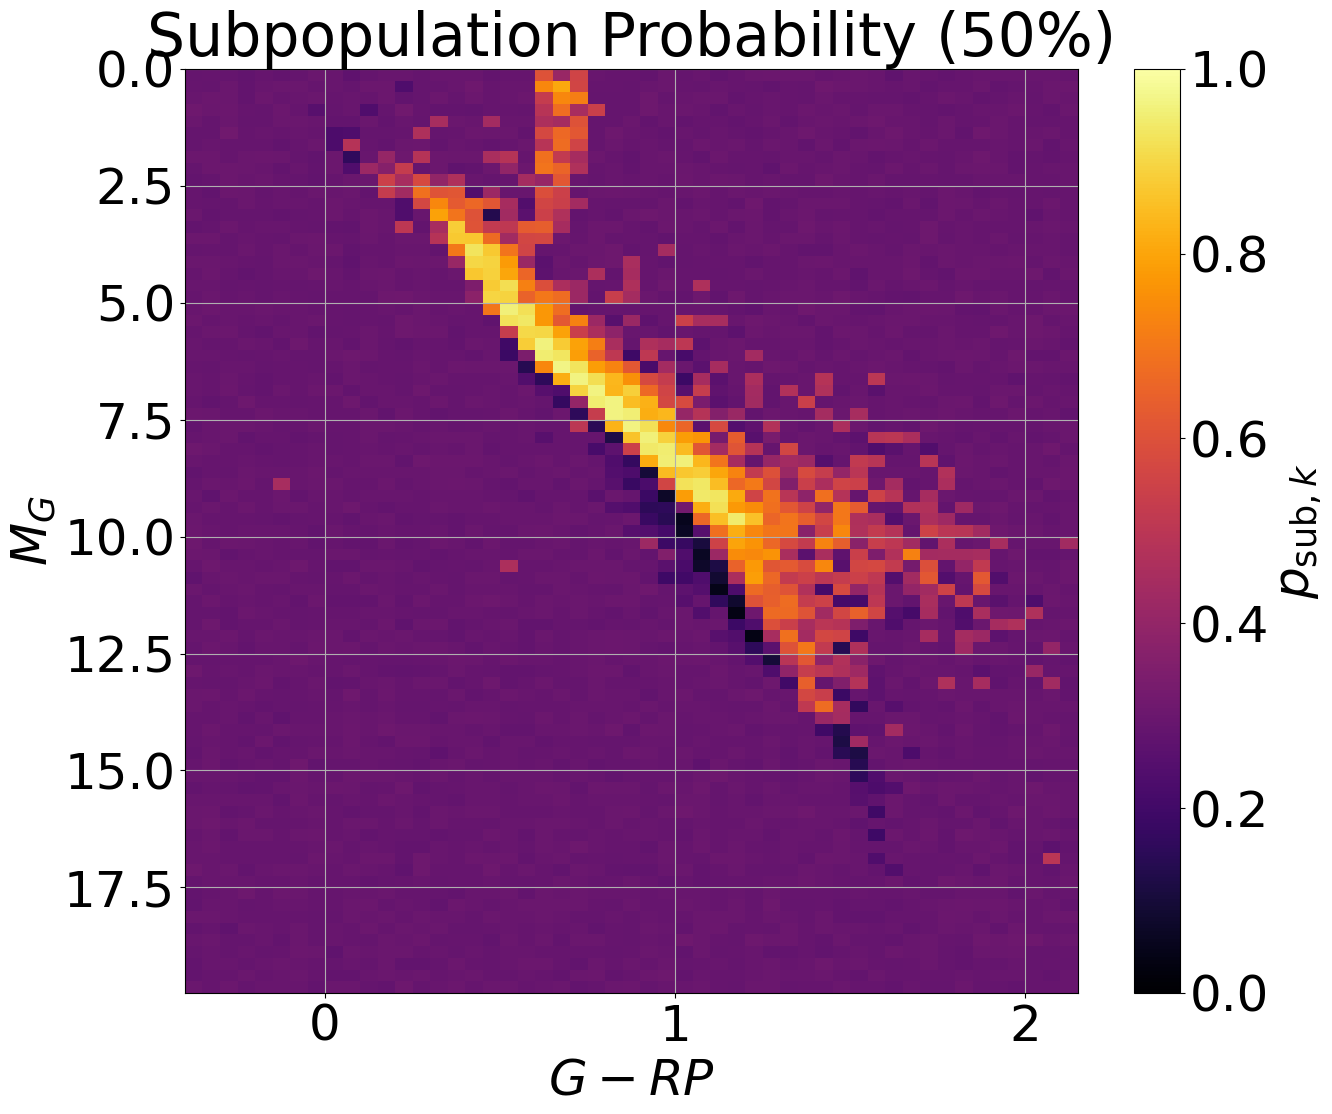

In [4]:
# have the bins for plotting
g_rp_bins = np.arange(*sf.sf_bins['g_rp'])
MG_bins = np.arange(*MG_bin_list)

# numbers in bin for reshaping the flattened p_samples
n_g_rp = len(g_rp_bins) - 1
n_mg = len(MG_bins) - 1

# get the 50th percentile of the samples in 2D array
p_50perc = np.nanpercentile(p_samples.reshape((-1, n_g_rp, n_mg)), 50, axis=0)

# plot the results
f, ax1 = plt.subplots(1, 1, figsize=(12 * 1.2, 10 * 1.2))
dens = ax1.imshow(p_50perc.T,
                  origin='lower', aspect='auto',
                  extent=(g_rp_bins.min(), g_rp_bins.max(), MG_bins.min(), MG_bins.max()),
                  vmin=0, vmax=1, cmap='inferno')
ax1.set_xlabel(r'$G-RP$')
ax1.set_ylabel(r'$M_G$')
ax1.invert_yaxis()
ax1.grid()
ax1.set_title('Subpopulation Probability (50%)')
plt.colorbar(dens, ax=ax1, label=r'$p_{\mathsf{sub}, k}$')
plt.savefig('paper_plots/appendix_ex/subpop_prob.png', bbox_inches='tight')
plt.show()


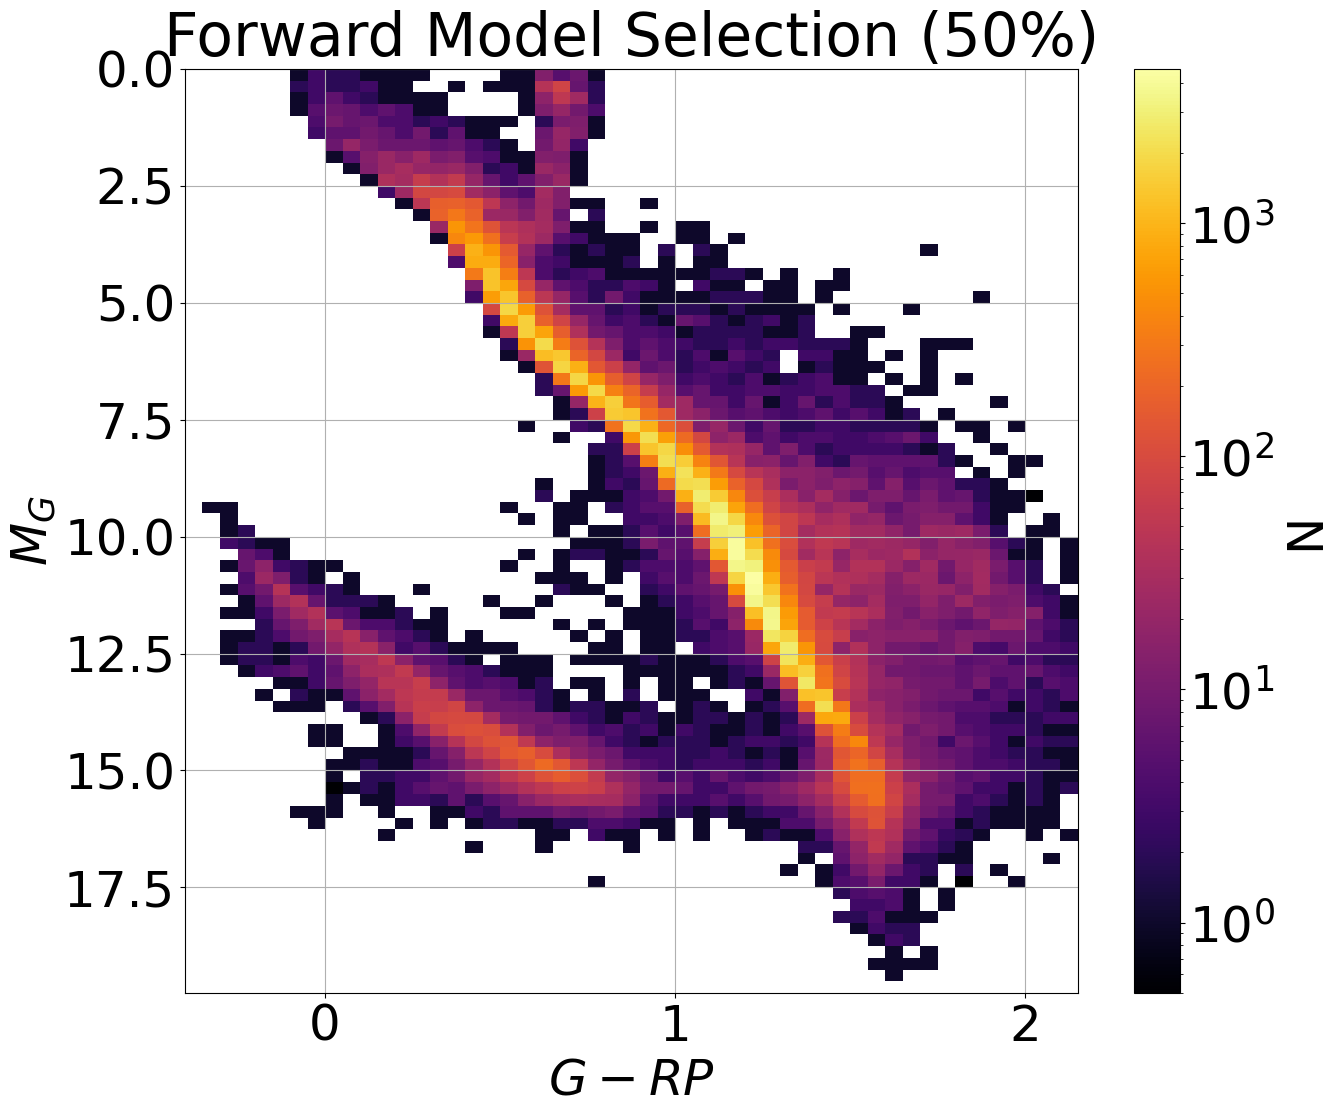

In [5]:
# random seed to reproduce results
RNG = np.random.default_rng(666)

# get the total number of stars in the GCNS across the HR diagram
gcns_filter = sf.gcns.filter(pl.Series(sf.gcns_valid))
Ntot, _, _ = np.histogram2d(gcns_filter['g_rp'].to_numpy(), gcns_filter['MG'].to_numpy(),
                            bins=[g_rp_bins, MG_bins])

# based on p_samples, draw number in subpopulation
Nsub = RNG.binomial(Ntot.astype(int), p_samples.reshape((-1, n_g_rp, n_mg)))

# get 50th percentile
Nsub_50perc = np.nanpercentile(Nsub, 50, axis=0)

# plot the results
f, ax1 = plt.subplots(1, 1, figsize=(12 * 1.2, 10 * 1.2))
dens = ax1.imshow(Nsub_50perc.T,
                  origin='lower', aspect='auto',
                  extent=(g_rp_bins.min(), g_rp_bins.max(), MG_bins.min(), MG_bins.max()),
                  norm=LogNorm(), cmap='inferno')
ax1.set_xlabel(r'$G-RP$')
ax1.set_ylabel(r'$M_G$')
ax1.invert_yaxis()
ax1.grid()
ax1.set_title('Forward Model Selection (50%)')
plt.colorbar(dens, ax=ax1, label='N')
plt.savefig('paper_plots/appendix_ex/subpop_select.png', bbox_inches='tight')
plt.show()
